# TTS-Portuguese Corpus: Exploratory Data Analysis

Analysis of mel-spectrogram dimensions from the TTS-Portuguese Corpus. This notebook explores:
- Dimension statistics and distributions
- t-SNE embeddings for visualization
- Correlation patterns between mel bins
- Duration statistics and patterns

In [1]:
import sys
import os
from pathlib import Path

os.chdir(Path.cwd().parent) 
sys.path.insert(0, str(Path.cwd() / "scripts" / "utils"))


import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_mel_metadata, load_mel_tensors, analyze_mel_dimensions,
    plot_dimension_histograms, compute_tsne, plot_tsne_2d, plot_tsne_3d,
    plot_duration_distribution, compute_dimension_correlations, plot_correlation_matrix
)

# Setup paths
corpus_dir = Path("data/processed/tts-portuguese-Corpora")
mels_metadata_csv = corpus_dir / "mels_metadata.csv"
figs_dir = corpus_dir / "figures"
figs_dir.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Corpus directory: {corpus_dir}")
print(f"Metadata file: {mels_metadata_csv}")
print(f"Figures directory: {figs_dir}")

Working directory: /home/richard/project/ml2_final_project
Corpus directory: data/processed/tts-portuguese-Corpora
Metadata file: data/processed/tts-portuguese-Corpora/mels_metadata.csv
Figures directory: data/processed/tts-portuguese-Corpora/figures


## 1. Load Mel Spectrogram Data

In [2]:

metadata = load_mel_metadata(mels_metadata_csv)
print(f"Loaded {len(metadata)} mel spectrogram entries")

# Load mel tensors (aggregate time dimension by mean)
features, valid_metadata = load_mel_tensors(metadata)
print(f"Loaded {len(features)} mel features with shape {features.shape}")
print(f"Features: {features.shape[0]} samples × {features.shape[1]} mel bins (time-aggregated)")
print(f"\nFeature statistics:")
print(f"  Min: {features.min():.4f}")
print(f"  Max: {features.max():.4f}")
print(f"  Mean: {features.mean():.4f}")
print(f"  Std: {features.std():.4f}")


Loaded 120 mel spectrogram entries
Loaded 120 mel features with shape (120, 80)
Features: 120 samples × 80 mel bins (time-aggregated)

Feature statistics:
  Min: -10.9719
  Max: 11.9804
  Mean: 0.1534
  Std: 4.0322


## 2. Analyze Mel Dimension Statistics

In [3]:

# Compute dimension statistics
mel_names = [f"Mel {i}" for i in range(features.shape[1])]
stats = analyze_mel_dimensions(features, names=mel_names)

# Display summary
print("Dimension Statistics Summary:")
print(f"{'Dimension':<12} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for i in range(min(10, len(mel_names))):
    print(f"{mel_names[i]:<12} {stats['mean'][i]:>11.4f} {stats['std'][i]:>11.4f} "
          f"{stats['min'][i]:>11.4f} {stats['max'][i]:>11.4f}")
if len(mel_names) > 10:
    print(f"... ({len(mel_names) - 10} more dimensions)")

# Create a DataFrame for easier analysis
stats_df = pd.DataFrame({
    'Dimension': mel_names,
    'Mean': stats['mean'],
    'Std': stats['std'],
    'Min': stats['min'],
    'Max': stats['max'],
    'Median': stats['median'],
    'Q25': stats['q25'],
    'Q75': stats['q75'],
})
print("\nFull Statistics DataFrame:")
print(stats_df.describe())


Dimension Statistics Summary:
Dimension    Mean         Std          Min          Max         
------------------------------------------------------------
Mel 0            -6.3624      2.1420    -10.8523      0.6957
Mel 1            -5.6183      2.0796    -10.3760      0.4791
Mel 2            -4.5278      2.2771     -9.8872      3.7771
Mel 3            -0.9944      3.5020     -7.8054      9.4406
Mel 4             3.0503      3.8793     -7.6461     11.8065
Mel 5             5.4927      3.2987     -6.9236     11.6023
Mel 6             6.0096      2.5351     -1.0363     11.2595
Mel 7             1.6035      2.7855     -4.2166     10.7586
Mel 8             1.0715      3.5169     -5.5855     10.5859
Mel 9             1.9457      3.7559     -4.8769     11.9388
... (70 more dimensions)

Full Statistics DataFrame:
            Mean        Std        Min        Max     Median        Q25  \
count  80.000000  80.000000  80.000000  80.000000  80.000000  80.000000   
mean    0.153421   2.281087  -6

## 3. Plot Histograms of Mel Dimension Variation

Saved to data/processed/tts-portuguese-Corpora/figures/mel_dimension_histograms.png


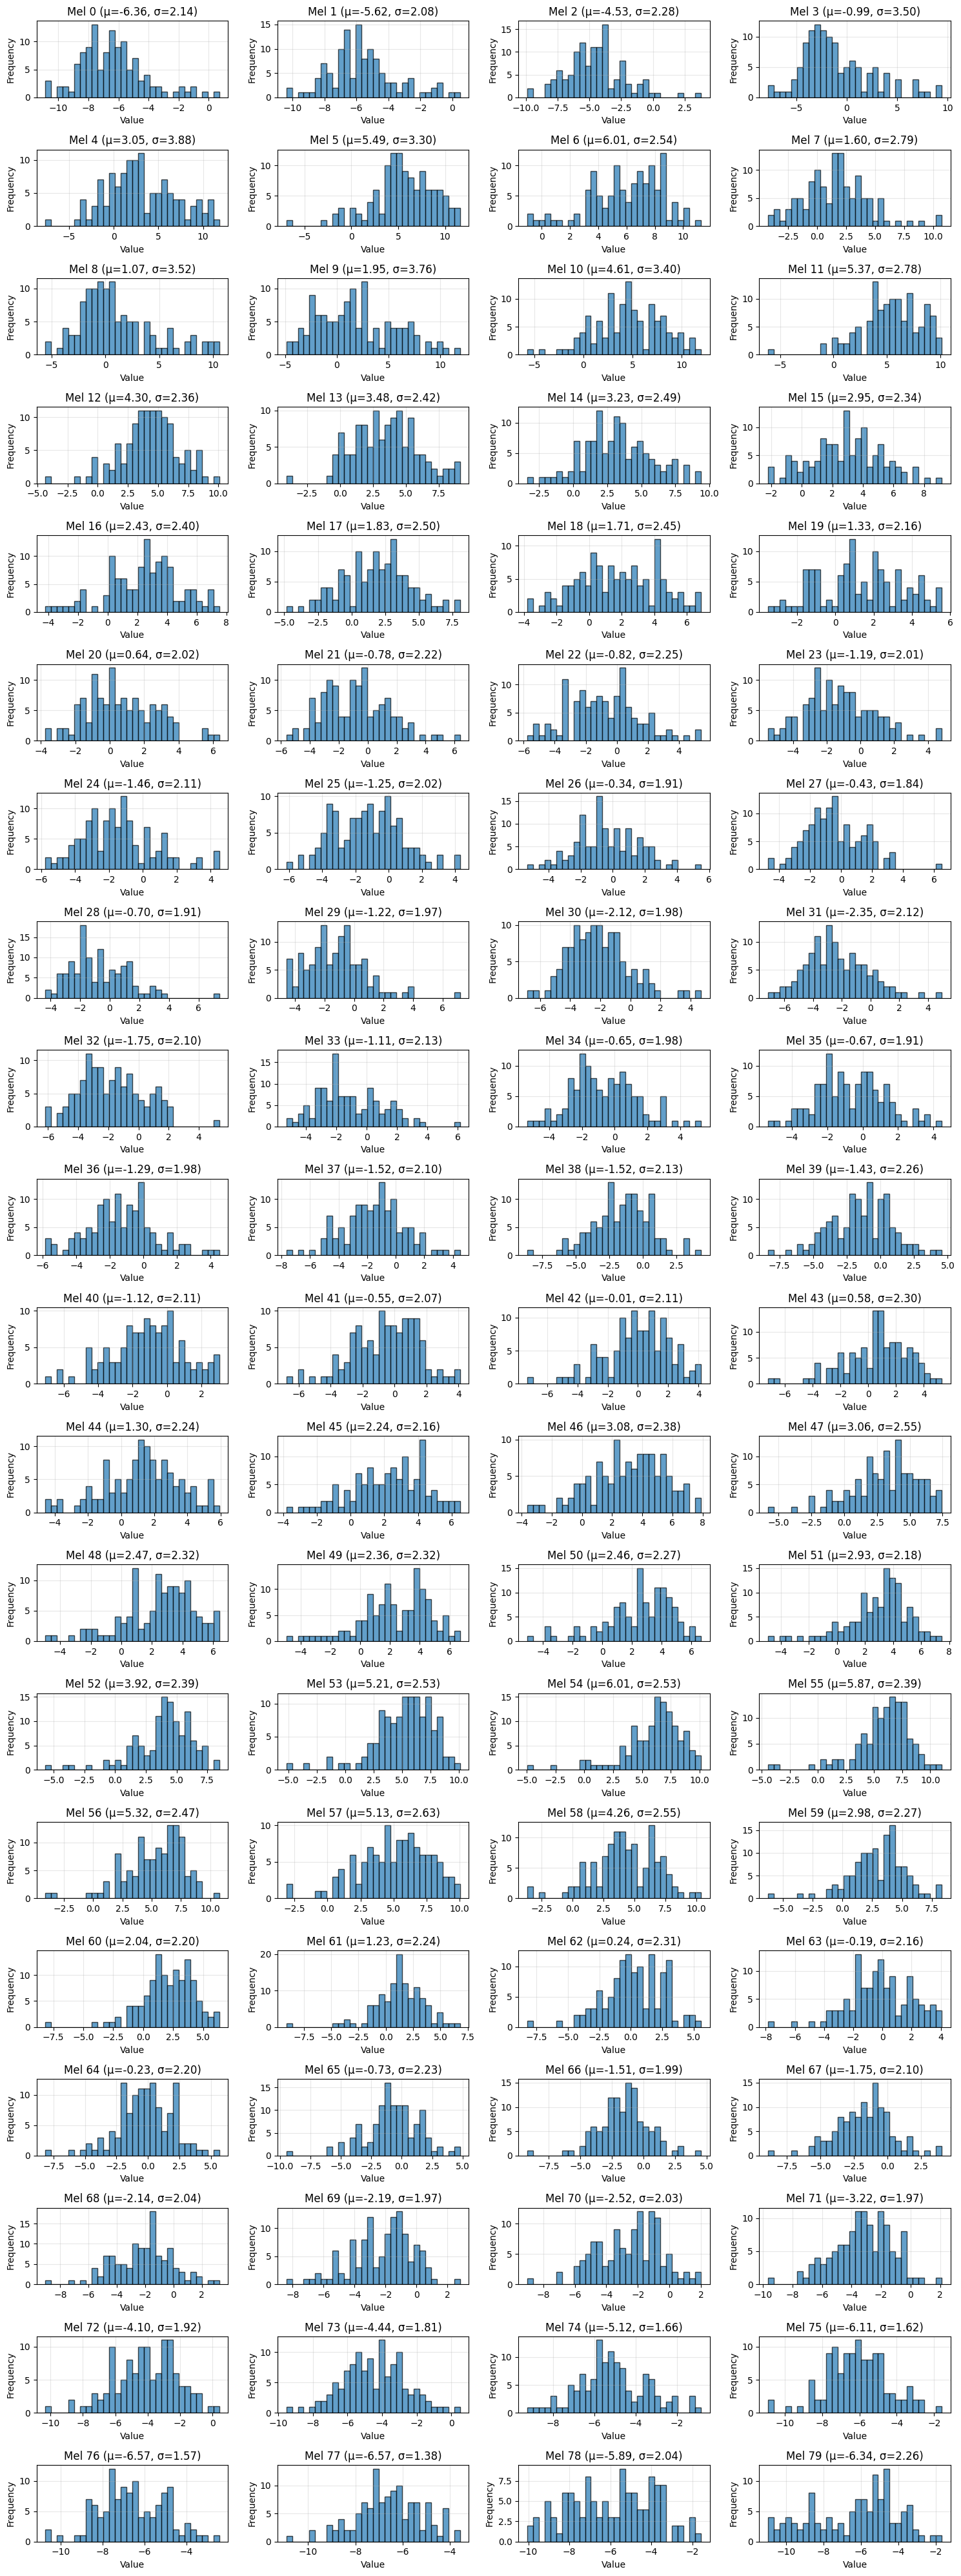

In [4]:

plot_dimension_histograms(
    features,
    names=mel_names,
    bins=30,
    figsize=(15, 40),
    save_path=figs_dir / "mel_dimension_histograms.png"
)


## 4. Analyze Duration Distribution

Duration Statistics:
  Count: 120
  Min: 1.0006s
  Max: 2.2761s
  Mean: 1.2154s
  Median: 1.1386s
  Std: 0.2441s
  Total audio: 145.85s = 2.43 minutes
Saved to data/processed/tts-portuguese-Corpora/figures/duration_distribution.png


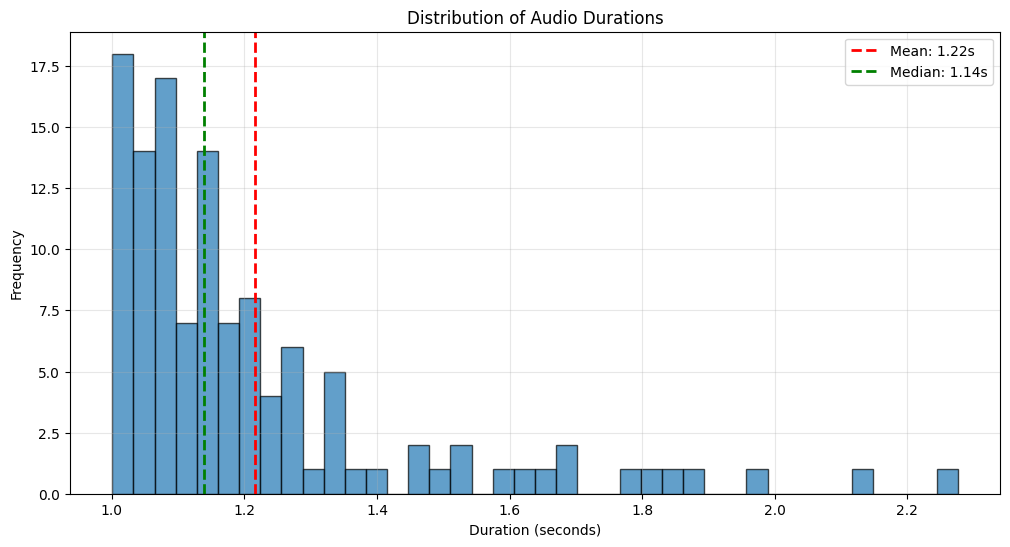

In [5]:

# Analyze durations
durations = np.array([m.get("duration", 0.0) for m in valid_metadata])
print(f"Duration Statistics:")
print(f"  Count: {len(durations)}")
print(f"  Min: {durations.min():.4f}s")
print(f"  Max: {durations.max():.4f}s")
print(f"  Mean: {durations.mean():.4f}s")
print(f"  Median: {np.median(durations):.4f}s")
print(f"  Std: {durations.std():.4f}s")
print(f"  Total audio: {durations.sum():.2f}s = {durations.sum()/60:.2f} minutes")

# Plot duration distribution
plot_duration_distribution(
    valid_metadata,
    bins=40,
    figsize=(12, 6),
    save_path=figs_dir / "duration_distribution.png"
)


## 5. Analyze Dimension Correlations

Correlation Matrix Shape: (80, 80)

High Correlations (|r| > 0.7): 180 pairs
  Mel 0 <-> Mel 1: 0.9614
  Mel 1 <-> Mel 2: 0.7577
  Mel 2 <-> Mel 3: 0.8419
  Mel 2 <-> Mel 8: 0.7325
  Mel 3 <-> Mel 4: 0.8407
  Mel 3 <-> Mel 8: 0.8315
  Mel 3 <-> Mel 9: 0.7577
  Mel 4 <-> Mel 5: 0.7520
  Mel 4 <-> Mel 9: 0.8994
  Mel 4 <-> Mel 10: 0.7729
  ... and 170 more


Saved to data/processed/tts-portuguese-Corpora/figures/dimension_correlations.png


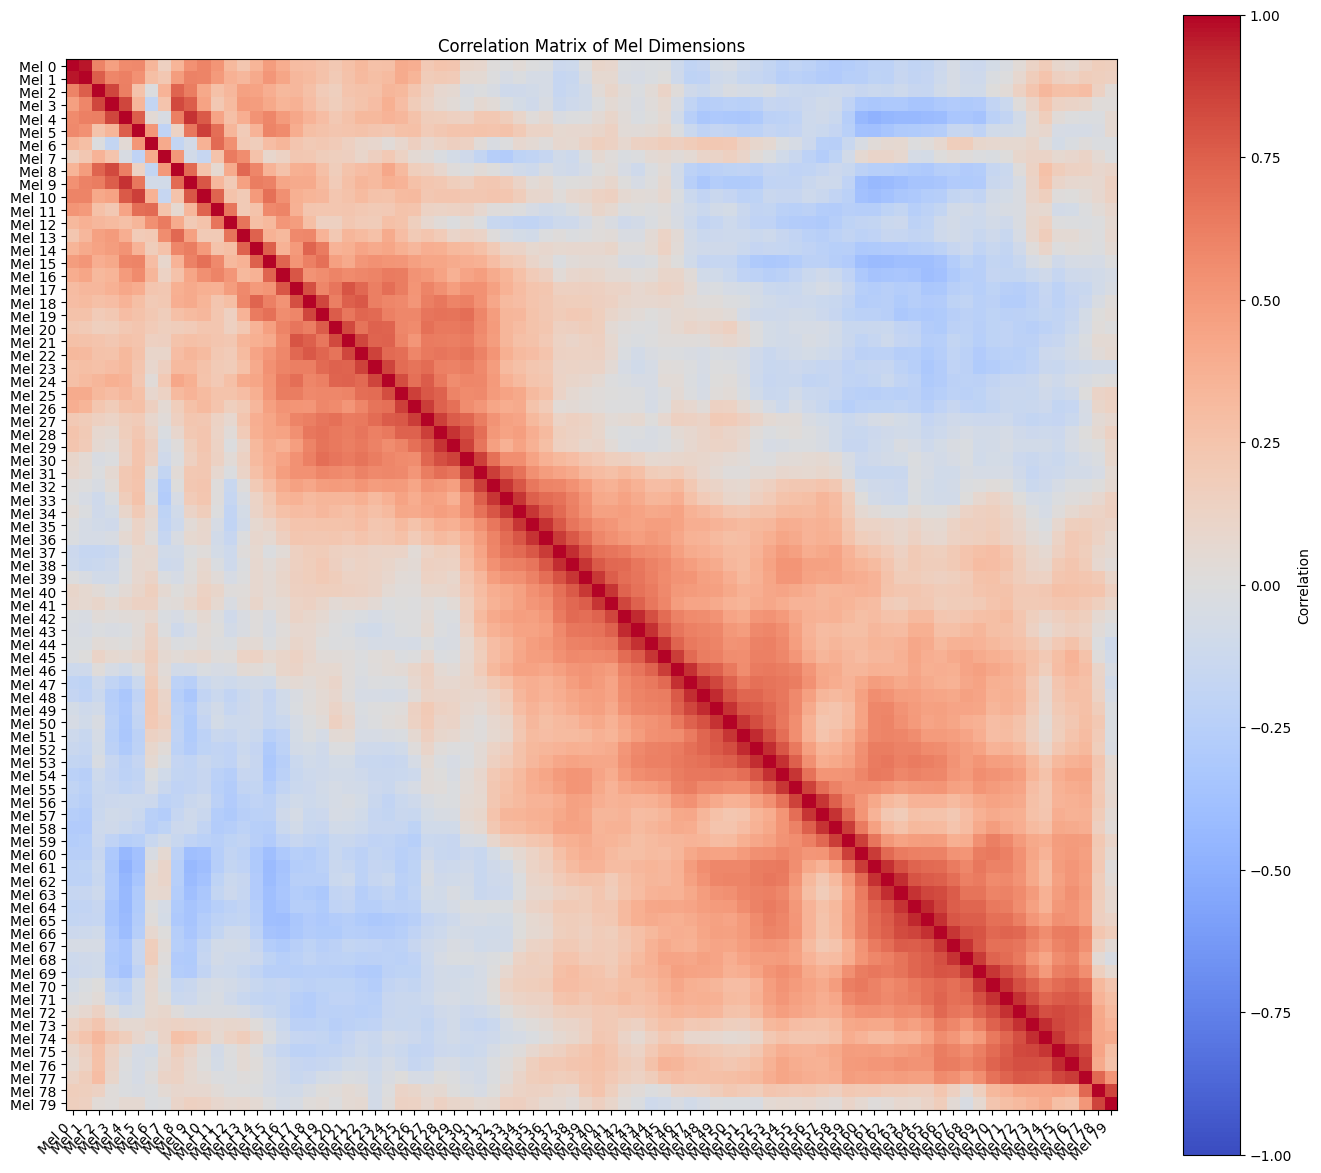

In [6]:

# Compute correlation matrix
corr_matrix = compute_dimension_correlations(features, names=mel_names)
print(f"Correlation Matrix Shape: {corr_matrix.shape}")

# Show high correlations (> 0.7 or < -0.7)
high_corr_pairs = []
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[1]):
        if abs(corr_matrix[i, j]) > 0.7:
            high_corr_pairs.append((i, j, corr_matrix[i, j]))

print(f"\nHigh Correlations (|r| > 0.7): {len(high_corr_pairs)} pairs")
for i, j, r in high_corr_pairs[:10]:
    print(f"  {mel_names[i]} <-> {mel_names[j]}: {r:.4f}")
if len(high_corr_pairs) > 10:
    print(f"  ... and {len(high_corr_pairs) - 10} more")

# Plot correlation matrix
plot_correlation_matrix(
    corr_matrix,
    names=mel_names,
    figsize=(14, 12),
    save_path=figs_dir / "dimension_correlations.png"
)


## 6. Compute and Visualize t-SNE (2D)

Computing 2D t-SNE embedding...
Computing t-SNE (120 samples, 80 dims)...
t-SNE complete. Embedding shape: (120, 2)

Plotting t-SNE 2D (uniform color)...
Saved to data/processed/tts-portuguese-Corpora/figures/tsne_2d_uniform.png


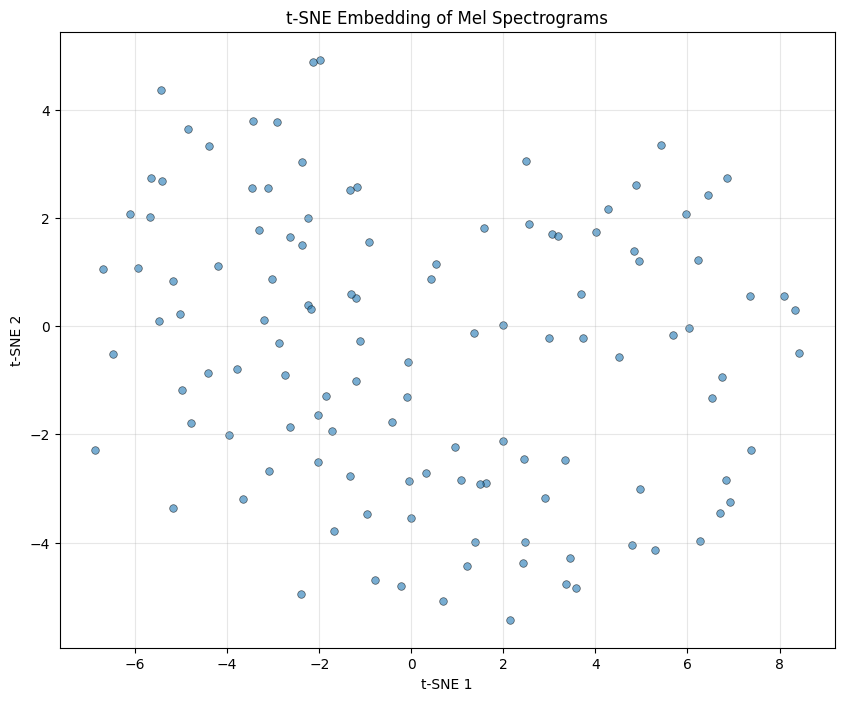

Plotting t-SNE 2D (colored by duration)...
Saved to data/processed/tts-portuguese-Corpora/figures/tsne_2d_duration.png


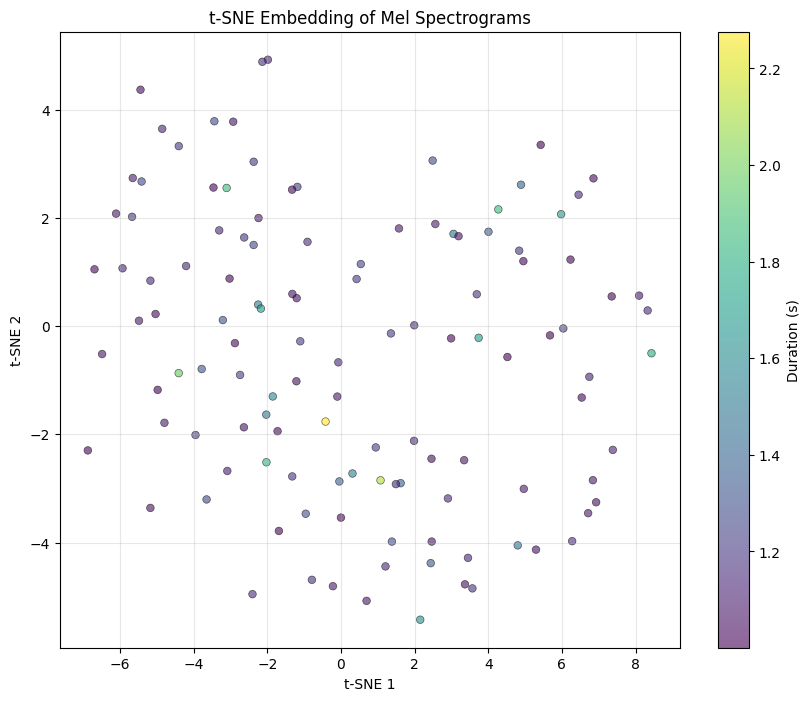

In [7]:

# Compute 2D t-SNE embedding
print("Computing 2D t-SNE embedding...")
tsne_2d = compute_tsne(features, n_components=2, perplexity=30, random_state=42)

# Plot without coloring
print("\nPlotting t-SNE 2D (uniform color)...")
plot_tsne_2d(
    tsne_2d,
    valid_metadata,
    color_by=None,
    figsize=(10, 8),
    save_path=figs_dir / "tsne_2d_uniform.png"
)

# Plot colored by duration
print("Plotting t-SNE 2D (colored by duration)...")
plot_tsne_2d(
    tsne_2d,
    valid_metadata,
    color_by="duration",
    figsize=(10, 8),
    save_path=figs_dir / "tsne_2d_duration.png"
)


## 7. Compute and Visualize t-SNE (3D)

Computing 3D t-SNE embedding...
Computing t-SNE (120 samples, 80 dims)...
t-SNE complete. Embedding shape: (120, 3)

Plotting t-SNE 3D (uniform color)...
Saved to data/processed/tts-portuguese-Corpora/figures/tsne_3d_uniform.png


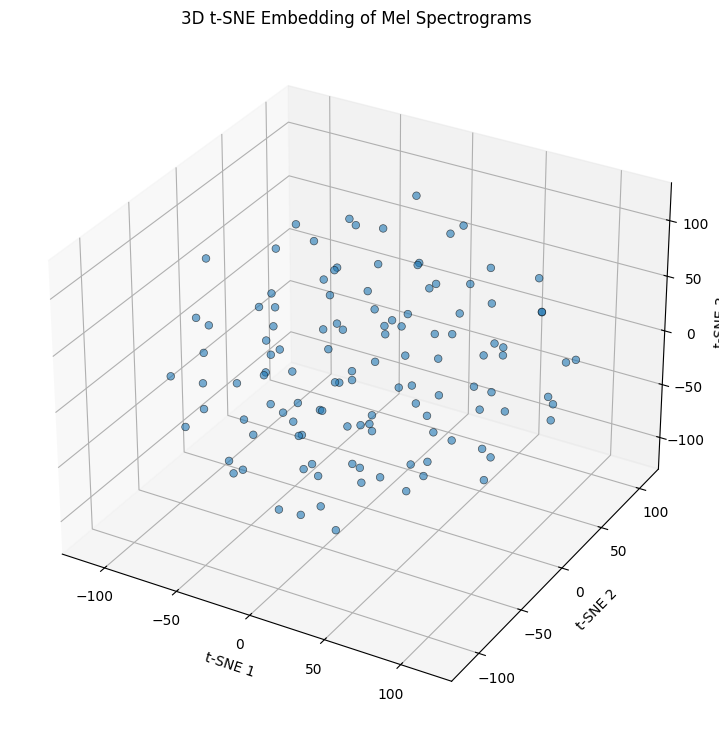

Plotting t-SNE 3D (colored by duration)...
Saved to data/processed/tts-portuguese-Corpora/figures/tsne_3d_duration.png


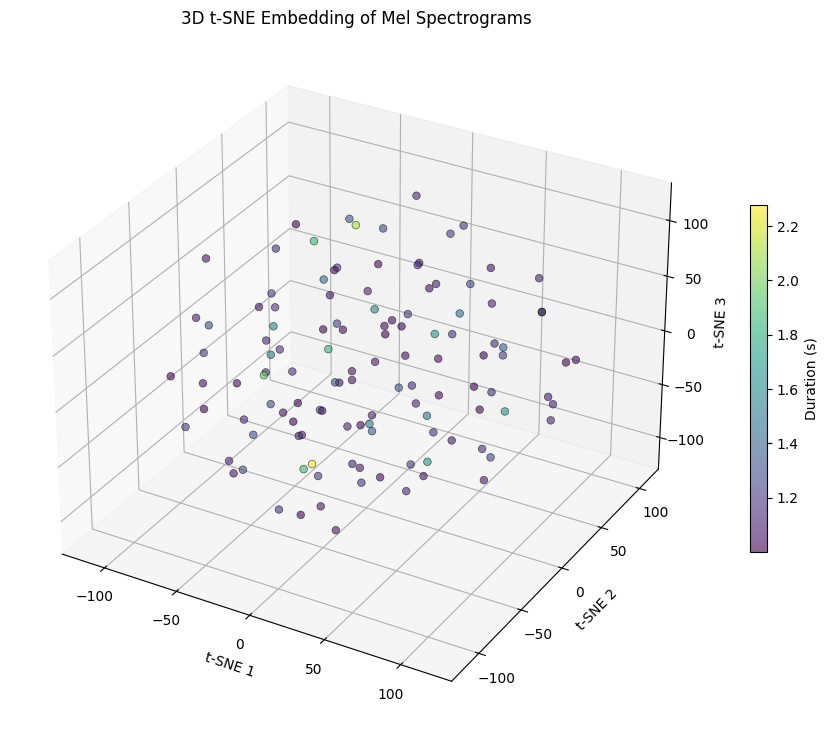

In [8]:

# Compute 3D t-SNE embedding
print("Computing 3D t-SNE embedding...")
tsne_3d = compute_tsne(features, n_components=3, perplexity=30, random_state=42)

# Plot 3D t-SNE without coloring
print("\nPlotting t-SNE 3D (uniform color)...")
plot_tsne_3d(
    tsne_3d,
    valid_metadata,
    color_by=None,
    figsize=(12, 9),
    save_path=figs_dir / "tsne_3d_uniform.png"
)

# Plot 3D t-SNE colored by duration
print("Plotting t-SNE 3D (colored by duration)...")
plot_tsne_3d(
    tsne_3d,
    valid_metadata,
    color_by="duration",
    figsize=(12, 9),
    save_path=figs_dir / "tsne_3d_duration.png"
)


## 8. Summary and Key Insights

In [9]:

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print("\n1. DATASET OVERVIEW")
print(f"   - Total samples: {len(features)}")
print(f"   - Mel dimensions: {features.shape[1]}")
print(f"   - Total audio duration: {durations.sum()/60:.2f} minutes")
print(f"   - Average duration: {durations.mean():.2f}s (min: {durations.min():.2f}s, max: {durations.max():.2f}s)")

print("\n2. MEL FEATURE STATISTICS")
print(f"   - Feature range: [{features.min():.4f}, {features.max():.4f}]")
print(f"   - Mean value: {features.mean():.4f}")
print(f"   - Std deviation: {features.std():.4f}")

print("\n3. DIMENSION ANALYSIS")
# Find most and least varying dimensions
var_per_dim = features.std(axis=0)
top_var_idx = np.argsort(var_per_dim)[-5:][::-1]
low_var_idx = np.argsort(var_per_dim)[:5]

print("   Most variable dimensions:")
for idx in top_var_idx:
    print(f"     - {mel_names[idx]}: σ = {var_per_dim[idx]:.4f}")

print("\n   Least variable dimensions:")
for idx in low_var_idx:
    print(f"     - {mel_names[idx]}: σ = {var_per_dim[idx]:.4f}")

print(f"\n4. DIMENSION CORRELATIONS")
print(f"   - High correlations (|r| > 0.7): {len(high_corr_pairs)} pairs")
print(f"   - Suggests moderate redundancy in mel representation")

print("\n5. CLUSTERING INSIGHTS (from t-SNE)")
print("   - 2D t-SNE: Reveals 2D structure of mel spectrogram distribution")
print("   - 3D t-SNE: Captures additional structure in 3D space")
print("   - t-SNE colored by duration shows duration-related clustering patterns")

print("\n6. RECOMMENDATIONS FOR MODEL TRAINING")
print("   - Consider dimensionality reduction (e.g., PCA, autoencoders)")
print("   - High correlations suggest potential for feature engineering")
print("   - Normalized mel features may improve model convergence")
print("   - Consider stratified sampling by duration for balanced training")

print("\n7. OUTPUT FILES SAVED")
print(f"   - Dimension histograms: {figs_dir / 'mel_dimension_histograms.png'}")
print(f"   - Duration distribution: {figs_dir / 'duration_distribution.png'}")
print(f"   - Correlation matrix: {figs_dir / 'dimension_correlations.png'}")
print(f"   - t-SNE 2D (uniform): {figs_dir / 'tsne_2d_uniform.png'}")
print(f"   - t-SNE 2D (by duration): {figs_dir / 'tsne_2d_duration.png'}")
print(f"   - t-SNE 3D (uniform): {figs_dir / 'tsne_3d_uniform.png'}")
print(f"   - t-SNE 3D (by duration): {figs_dir / 'tsne_3d_duration.png'}")

print("\n" + "=" * 70)


EXPLORATORY DATA ANALYSIS SUMMARY

1. DATASET OVERVIEW
   - Total samples: 120
   - Mel dimensions: 80
   - Total audio duration: 2.43 minutes
   - Average duration: 1.22s (min: 1.00s, max: 2.28s)

2. MEL FEATURE STATISTICS
   - Feature range: [-10.9719, 11.9804]
   - Mean value: 0.1534
   - Std deviation: 4.0322

3. DIMENSION ANALYSIS
   Most variable dimensions:
     - Mel 4: σ = 3.8793
     - Mel 9: σ = 3.7559
     - Mel 8: σ = 3.5169
     - Mel 3: σ = 3.5020
     - Mel 10: σ = 3.4012

   Least variable dimensions:
     - Mel 77: σ = 1.3806
     - Mel 76: σ = 1.5680
     - Mel 75: σ = 1.6248
     - Mel 74: σ = 1.6632
     - Mel 73: σ = 1.8092

4. DIMENSION CORRELATIONS
   - High correlations (|r| > 0.7): 180 pairs
   - Suggests moderate redundancy in mel representation

5. CLUSTERING INSIGHTS (from t-SNE)
   - 2D t-SNE: Reveals 2D structure of mel spectrogram distribution
   - 3D t-SNE: Captures additional structure in 3D space
   - t-SNE colored by duration shows duration-related c

## 9. Advanced Analysis: PCA for Dimensionality Reduction

Computing PCA...


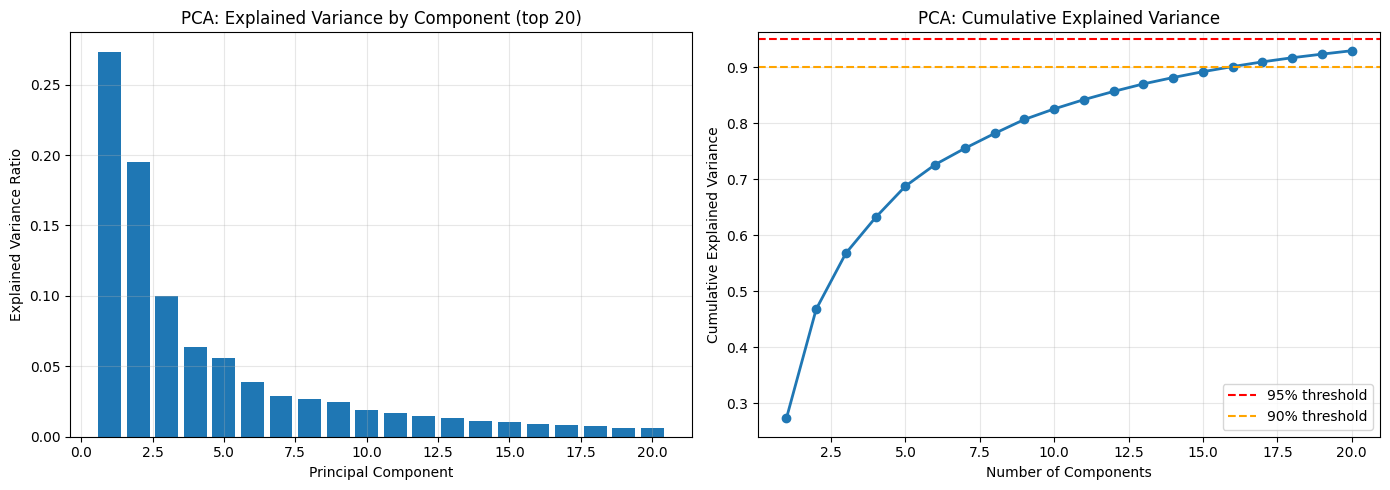


PCA Analysis Results:
  - Components for 90% variance: 16
  - Components for 95% variance: 25
  - Total variance explained by all 80 components: 1.0000
  - Dimension reduction: 80 -> 25 (for 95% var)


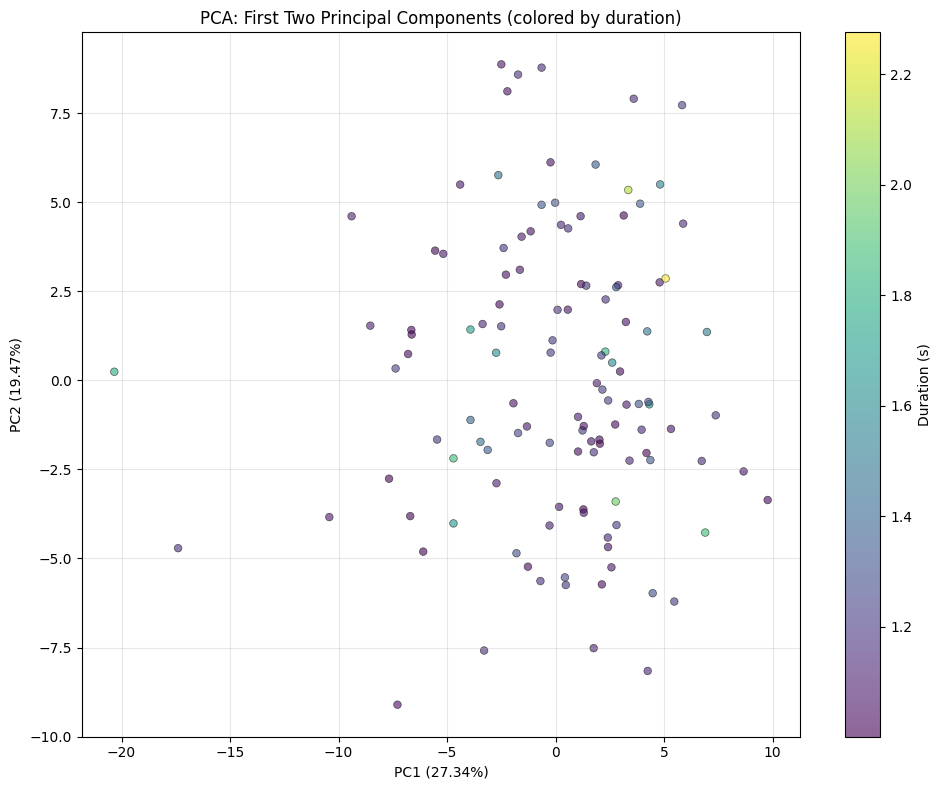

In [10]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Compute PCA
print("Computing PCA...")
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA()
pca_features = pca.fit_transform(features_scaled)

# Plot cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variances
ax1.bar(range(1, min(21, len(pca.explained_variance_ratio_) + 1)), 
        pca.explained_variance_ratio_[:20])
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA: Explained Variance by Component (top 20)")
ax1.grid(alpha=0.3)

# Cumulative variance
ax2.plot(range(1, min(21, len(cumsum_var) + 1)), cumsum_var[:20], 'o-', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("PCA: Cumulative Explained Variance")
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(figs_dir / "pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1

print(f"\nPCA Analysis Results:")
print(f"  - Components for 90% variance: {n_components_90}")
print(f"  - Components for 95% variance: {n_components_95}")
print(f"  - Total variance explained by all {len(pca.explained_variance_ratio_)} components: {cumsum_var[-1]:.4f}")
print(f"  - Dimension reduction: {features.shape[1]} -> {n_components_95} (for 95% var)")

# Plot PCA scores in 2D
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pca_features[:, 0], pca_features[:, 1], 
                    c=durations, cmap='viridis', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("PCA: First Two Principal Components (colored by duration)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Duration (s)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(figs_dir / "pca_2d_duration.png", dpi=150, bbox_inches='tight')
plt.show()
